# Stage 6: Machine Learning Model Development
## Logistic Regression (LR)



## 1. Environment & Library Configuration


In [2]:
import os
import gc
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
print("Environment and ML libraries successfully loaded.")


Environment and ML libraries successfully loaded.


## 2. Dataset Loading & Common Split Verification

Following the team's data preparation standard (Notebook `03_data_preparation.ipynb`), the data is partitioned chronologically:
* **Training Set**: $2013–2020$ ($year \le 2020$)
* **Validation Set**: $2021–2022$ ($2021 \le year \le 2022$)
* **Test Set**: $2023–2025$ ($year \ge 2023$)

We check for split files or dynamically partition from `wildfire_processed.csv`.


In [3]:
PROCESSED_DIR = "../../data/processed"
TRAIN_PATH = os.path.join(PROCESSED_DIR, "train.csv")
VAL_PATH = os.path.join(PROCESSED_DIR, "validation.csv")
TEST_PATH = os.path.join(PROCESSED_DIR, "test.csv")
FULL_PROCESSED_PATH = os.path.join(PROCESSED_DIR, "wildfire_processed.csv")

if os.path.exists(TRAIN_PATH) and os.path.exists(VAL_PATH) and os.path.exists(TEST_PATH):
    print("Loading existing train, validation, and test split files...")
    train_df = pd.read_csv(TRAIN_PATH)
    val_df = pd.read_csv(VAL_PATH)
    test_df = pd.read_csv(TEST_PATH)
elif os.path.exists(FULL_PROCESSED_PATH):
    print("Partitioning directly from wildfire_processed.csv using team chronological split...")
    df = pd.read_csv(FULL_PROCESSED_PATH)
    train_df = df[df["year"] <= 2020].copy()
    val_df = df[(df["year"] >= 2021) & (df["year"] <= 2022)].copy()
    test_df = df[df["year"] >= 2023].copy()
    del df
    gc.collect()
else:
    raise FileNotFoundError("Processed wildfire dataset not found in data/processed/")

print(f"Train set shape:      {train_df.shape} (Years: {train_df['year'].min()} - {train_df['year'].max()})")
print(f"Validation set shape: {val_df.shape} (Years: {val_df['year'].min()} - {val_df['year'].max()})")
print(f"Test set shape:       {test_df.shape} (Years: {test_df['year'].min()} - {test_df['year'].max()})")


Loading existing train, validation, and test split files...
Train set shape:      (7319483, 21) (Years: 2013 - 2020)
Validation set shape: (1326842, 21) (Years: 2021 - 2022)
Test set shape:       (823955, 21) (Years: 2023 - 2025)


### Feature Matrix ($X$) and Target Vector ($y$) Separation

We extract the target column `Wildfire` (binary label: $0 = \text{No Wildfire}, 1 = \text{Wildfire}$) across all splits.


In [6]:
TARGET_COL = "wildfire"
FEATURE_COLS = [c for c in train_df.columns if c != TARGET_COL]

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL].astype(int)

X_val = val_df[FEATURE_COLS]
y_val = val_df[TARGET_COL].astype(int)

X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET_COL].astype(int)

# Free DataFrames to optimize memory
del train_df, val_df, test_df
gc.collect()

print(f"Number of input features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")


Number of input features: 20
Features: ['latitude', 'longitude', 'precipitation', 'relative_humidity_max', 'relative_humidity_min', 'specific_humidity', 'solar_radiation', 'temperature_min', 'temperature_max', 'wind_speed', 'burning_index', 'fuel_moisture_100hr', 'fuel_moisture_1000hr', 'energy_release_component', 'reference_evapotranspiration', 'potential_evapotranspiration', 'vapor_pressure_deficit', 'year', 'month', 'day_of_year']


### Target Class Distribution & Imbalance Check

We confirm the severity of class imbalance across all three splits.


In [7]:
dist_data = {
    "Train Count": y_train.value_counts(),
    "Train %": (y_train.value_counts(normalize=True) * 100).round(2),
    "Val Count": y_val.value_counts(),
    "Val %": (y_val.value_counts(normalize=True) * 100).round(2),
    "Test Count": y_test.value_counts(),
    "Test %": (y_test.value_counts(normalize=True) * 100).round(2),
}
class_summary = pd.DataFrame(dist_data)
class_summary.index = ["No wildfire (0)", "wildfire (1)"]
display(class_summary)

imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Training Imbalance Ratio (Negative : Positive): {imbalance_ratio:.2f} : 1")


,Train Count,Train %,Val Count,Val %,Test Count,Test %
No wildfire (0),7045069,96.25,1218614,91.84,705565,85.63
wildfire (1),274414,3.75,108228,8.16,118390,14.37


Training Imbalance Ratio (Negative : Positive): 25.67 : 1


## 3. Feature Scaling Pipeline (Zero Data Leakage)

* **Leakage Prevention**: We fit `StandardScaler` **strictly on $X_{train}$** and transform $X_{val}$ and $X_{test}$.


In [8]:
scaler = StandardScaler()

# Fit strictly on train data to prevent information leakage
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrames for feature tracking
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=FEATURE_COLS)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)

print("StandardScaler successfully fitted on training set and applied to validation/test sets.")
print(f"X_train_scaled max absolute mean: {X_train_scaled.mean().abs().max():.4f}")
print(f"X_train_scaled average std:       {X_train_scaled.std().mean():.4f}")


StandardScaler successfully fitted on training set and applied to validation/test sets.
X_train_scaled max absolute mean: 0.0000
X_train_scaled average std:       1.0000


## 4. Baseline Logistic Regression Model

### Training Configuration
The training partition contains ~7.3 million rows. 
* To ensure smooth execution on local hardware without memory exhaustion, we provide an interactive stratified sampling option (`SAMPLE_FOR_TRAINING = True`, $500,000$ samples).
* The **entire Validation Set (1.32M rows)** and **entire Test Set (824k rows)** are always evaluated at 100% full scale!
* We set `class_weight='balanced'` to prevent bias toward the majority class ($y=0$).


In [9]:
# Set to False to train on all 7.3M rows if high RAM is available
SAMPLE_FOR_TRAINING = True
SAMPLE_SIZE = 500000

if SAMPLE_FOR_TRAINING and len(X_train_scaled) > SAMPLE_SIZE:
    print(f"Using a representative stratified sample of {SAMPLE_SIZE:,} rows for rapid convergence...")
    from sklearn.model_selection import train_test_split
    X_fit, _, y_fit, _ = train_test_split(
        X_train_scaled, y_train,
        train_size=SAMPLE_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE
    )
else:
    print(f"Using full training dataset of {len(X_train_scaled):,} observations...")
    X_fit = X_train_scaled
    y_fit = y_train

print(f"Fitting set shape: {X_fit.shape}, wildfire positive rate: {(y_fit == 1).mean() * 100:.2f}%")


Using a representative stratified sample of 500,000 rows for rapid convergence...
Fitting set shape: (500000, 20), wildfire positive rate: 3.75%


In [10]:
print("Training Baseline Logistic Regression with class_weight='balanced'...")
start_time = time.time()

lr_baseline = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_baseline.fit(X_fit, y_fit)
baseline_train_time = time.time() - start_time

print(f"Baseline Logistic Regression trained in {baseline_train_time:.2f} seconds.")
print(f"Iterations completed: {lr_baseline.n_iter_[0]}")


Training Baseline Logistic Regression with class_weight='balanced'...
Baseline Logistic Regression trained in 1.13 seconds.
Iterations completed: 63


## 5. Validation Set Evaluation (Default Threshold $\tau = 0.5$)

We evaluate the baseline model on the unseen chronological validation split ($2021–2022$, $1.32	ext{M}$ records) using:
* **Confusion Matrix**
* **Precision, Recall, F1-Score** for the Wildfire class
* **ROC-AUC Score**
* **PR-AUC (Average Precision)**


In [11]:
# Predict probabilities on full validation set
y_val_proba_baseline = lr_baseline.predict_proba(X_val_scaled)[:, 1]
y_val_pred_baseline = (y_val_proba_baseline >= 0.5).astype(int)

# Calculate key validation metrics
roc_auc_base = roc_auc_score(y_val, y_val_proba_baseline)
pr_auc_base = average_precision_score(y_val, y_val_proba_baseline)
f1_base = f1_score(y_val, y_val_pred_baseline)
precision_base = precision_score(y_val, y_val_pred_baseline)
recall_base = recall_score(y_val, y_val_pred_baseline)

print("=" * 60)
print("   BASELINE LOGISTIC REGRESSION VALIDATION PERFORMANCE")
print("=" * 60)
print(f"Validation ROC-AUC Score:              {roc_auc_base:.4f}")
print(f"Validation PR-AUC (Average Precision): {pr_auc_base:.4f}")
print(f"Validation F1-Score (wildfire Class):  {f1_base:.4f}")
print(f"Validation Precision (wildfire Class): {precision_base:.4f}")
print(f"Validation Recall (wildfire Class):    {recall_base:.4f}")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_baseline, target_names=["No wildfire (0)", "wildfire (1)"]))


   BASELINE LOGISTIC REGRESSION VALIDATION PERFORMANCE
Validation ROC-AUC Score:              0.6038
Validation PR-AUC (Average Precision): 0.1073
Validation F1-Score (wildfire Class):  0.1582
Validation Precision (wildfire Class): 0.0861
Validation Recall (wildfire Class):    0.9759

Classification Report:
                 precision    recall  f1-score   support

No wildfire (0)       0.97      0.08      0.15   1218614
   wildfire (1)       0.09      0.98      0.16    108228

       accuracy                           0.15   1326842
      macro avg       0.53      0.53      0.15   1326842
   weighted avg       0.90      0.15      0.15   1326842



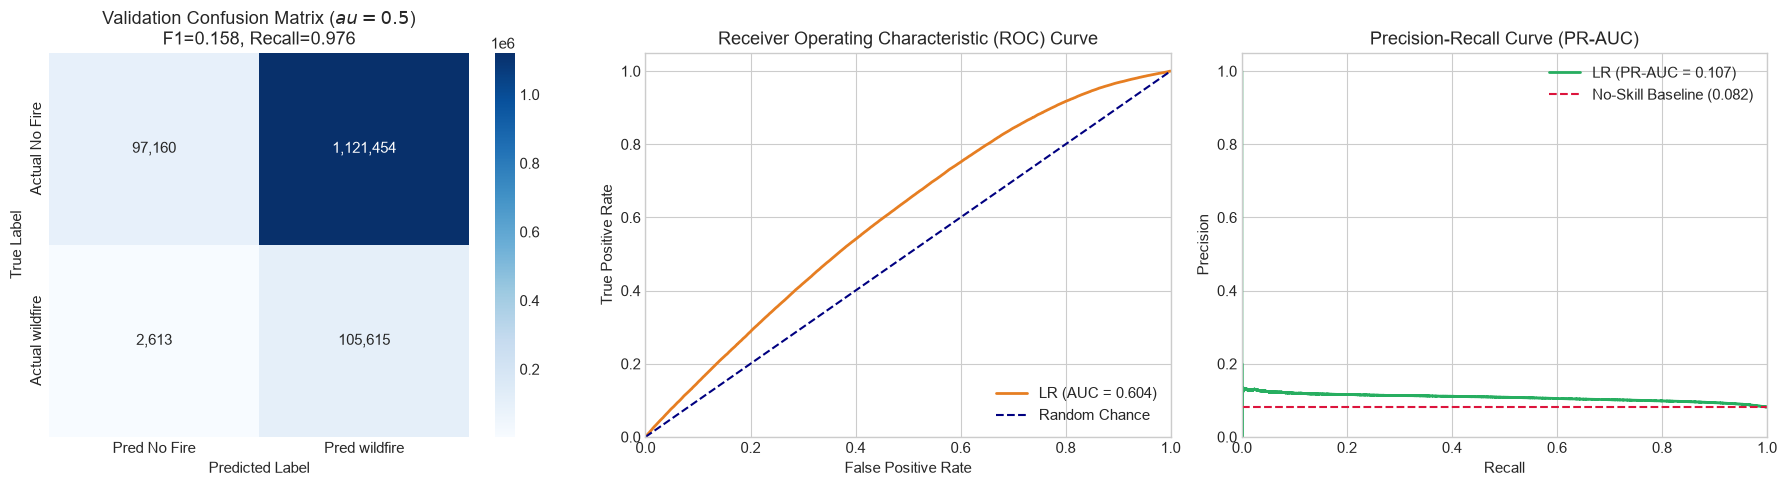

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_val, y_val_pred_baseline)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred No Fire', 'Pred wildfire'],
            yticklabels=['Actual No Fire', 'Actual wildfire'])
axes[0].set_title(f"Validation Confusion Matrix ($\tau=0.5$)\nF1={f1_base:.3f}, Recall={recall_base:.3f}")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_val_proba_baseline)
axes[1].plot(fpr, tpr, color='#e67e22', lw=2, label=f'LR (AUC = {roc_auc_base:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Chance')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1].legend(loc="lower right")

# 3. Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_val, y_val_proba_baseline)
baseline_ratio = y_val.mean()
axes[2].plot(rec_curve, prec_curve, color='#27ae60', lw=2, label=f'LR (PR-AUC = {pr_auc_base:.3f})')
axes[2].axhline(y=baseline_ratio, color='crimson', linestyle='--', label=f'No-Skill Baseline ({baseline_ratio:.3f})')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve (PR-AUC)')
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()


## 6. Decision Threshold Optimization

### Adapting to Class Imbalance on the Validation Set
Because `class_weight='balanced'` offsets class frequencies, the default $\tau = 0.50$ threshold is rarely optimal for F1-score.
We sweep thresholds $\tau \in [0.10, 0.90]$ strictly across validation predictions to identify the cutoff $\tau^*$ that maximizes the Wildfire F1-score.


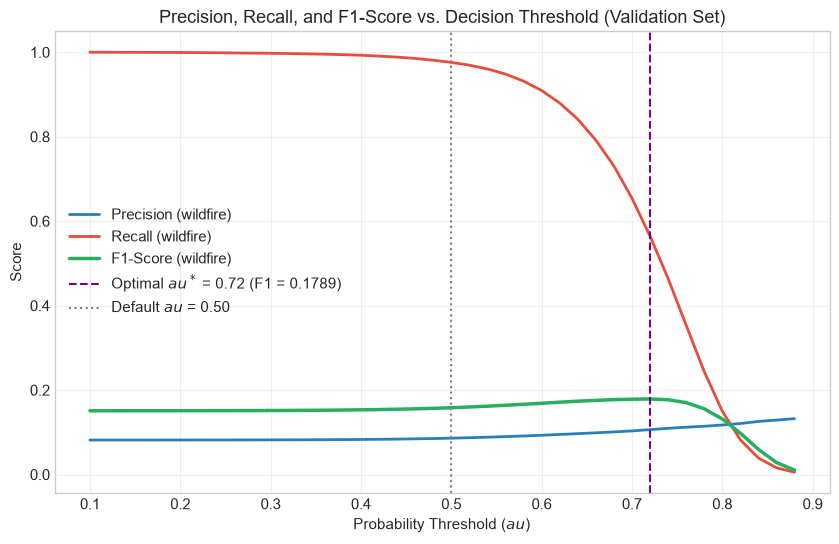

Optimal Decision Threshold:     0.72
F1-Score at Optimal Threshold:  0.1789 (vs 0.1582 at 0.50)
Precision at Optimal Threshold: 0.1063
Recall at Optimal Threshold:    0.5649


In [13]:
thresholds = np.arange(0.10, 0.90, 0.02)
t_precisions = []
t_recalls = []
t_f1s = []

for t in thresholds:
    preds = (y_val_proba_baseline >= t).astype(int)
    t_precisions.append(precision_score(y_val, preds, zero_division=0))
    t_recalls.append(recall_score(y_val, preds, zero_division=0))
    t_f1s.append(f1_score(y_val, preds, zero_division=0))

best_idx = np.argmax(t_f1s)
optimal_threshold = thresholds[best_idx]
best_val_f1 = t_f1s[best_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, t_precisions, label='Precision (wildfire)', color='#2980b9', lw=2)
plt.plot(thresholds, t_recalls, label='Recall (wildfire)', color='#e74c3c', lw=2)
plt.plot(thresholds, t_f1s, label='F1-Score (wildfire)', color='#27ae60', lw=2.5)
plt.axvline(optimal_threshold, color='purple', linestyle='--', label=f'Optimal $\tau^*$ = {optimal_threshold:.2f} (F1 = {best_val_f1:.4f})')
plt.axvline(0.50, color='gray', linestyle=':', label='Default $\tau$ = 0.50')

plt.title('Precision, Recall, and F1-Score vs. Decision Threshold (Validation Set)')
plt.xlabel('Probability Threshold ($\tau$)')
plt.ylabel('Score')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal Decision Threshold:     {optimal_threshold:.2f}")
print(f"F1-Score at Optimal Threshold:  {best_val_f1:.4f} (vs {f1_base:.4f} at 0.50)")
print(f"Precision at Optimal Threshold: {t_precisions[best_idx]:.4f}")
print(f"Recall at Optimal Threshold:    {t_recalls[best_idx]:.4f}")


## 7. Hyperparameter Tuning (Regularization Strength $C$)

We evaluate multiple regularization values $C \in [0.01, 0.1, 1.0, 10.0]$:
* Strong regularization ($C=0.01$): penalizes large coefficients, prevents overfitting.
* Moderate regularization ($C=0.1, 1.0$): standard balance.
* Weak regularization ($C=10.0$): allows maximum parameter variance.

The model with the highest validation PR-AUC / ROC-AUC is selected as the **Champion Configuration**.


In [14]:
c_values = [0.01, 0.1, 1.0, 10.0]
tuning_results = []
trained_models = {}

for c in c_values:
    print(f"Evaluating Logistic Regression with C={c}...")
    t0 = time.time()
    
    model = LogisticRegression(
        penalty='l2',
        C=c,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_STATE
    )
    model.fit(X_fit, y_fit)
    train_time = time.time() - t0
    
    val_probs = model.predict_proba(X_val_scaled)[:, 1]
    val_preds_opt = (val_probs >= optimal_threshold).astype(int)
    
    roc_auc = roc_auc_score(y_val, val_probs)
    pr_auc = average_precision_score(y_val, val_probs)
    f1 = f1_score(y_val, val_preds_opt)
    prec = precision_score(y_val, val_preds_opt, zero_division=0)
    rec = recall_score(y_val, val_preds_opt, zero_division=0)
    
    trained_models[c] = model
    tuning_results.append({
        "C": c,
        "Penalty": "L2 (Ridge)",
        "Train Time (s)": round(train_time, 2),
        "Val ROC-AUC": round(roc_auc, 4),
        "Val PR-AUC": round(pr_auc, 4),
        "Val F1 (Optimal Threshold)": round(f1, 4),
        "Val Precision": round(prec, 4),
        "Val Recall": round(rec, 4)
    })

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)

# Champion Model Selection based on Validation PR-AUC
best_c = tuning_df.sort_values(by="Val PR-AUC", ascending=False).iloc[0]["C"]
champion_lr = trained_models[best_c]
print(f"\nChampion Logistic Regression Selected: C = {best_c}")


Evaluating Logistic Regression with C=0.01...
Evaluating Logistic Regression with C=0.1...
Evaluating Logistic Regression with C=1.0...
Evaluating Logistic Regression with C=10.0...


,C,Penalty,Train Time (s),Val ROC-AUC,Val PR-AUC,Val F1 (Optimal Threshold),Val Precision,Val Recall
0,0.01,L2 (Ridge),1.08,0.6037,0.1073,0.1790,0.1066,0.5590
1,0.10,L2 (Ridge),1.67,0.6037,0.1073,0.1788,0.1063,0.5640
2,1.00,L2 (Ridge),1.50,0.6038,0.1073,0.1789,0.1063,0.5649
3,10.00,L2 (Ridge),1.44,0.6038,0.1073,0.1789,0.1063,0.5648



Champion Logistic Regression Selected: C = 0.01


## 8. Feature Interpretability & Odds Ratio Analysis

Logistic Regression parameters directly reveal the mathematical and physical relationship between environmental features and fire risk:
* **Coefficient $\beta_j$**: The change in log-odds of a wildfire per 1 standard deviation increase in feature $j$.
* **Odds Ratio ($	ext{OR}_j = e^{\beta_j}$)**:
  * $	ext{OR}_j > 1$: Increases wildfire risk (e.g. high temperatures, wind velocity, vapor pressure deficit).
  * $	ext{OR}_j < 1$: Suppresses wildfire risk (e.g. precipitation, fuel moisture, relative humidity).


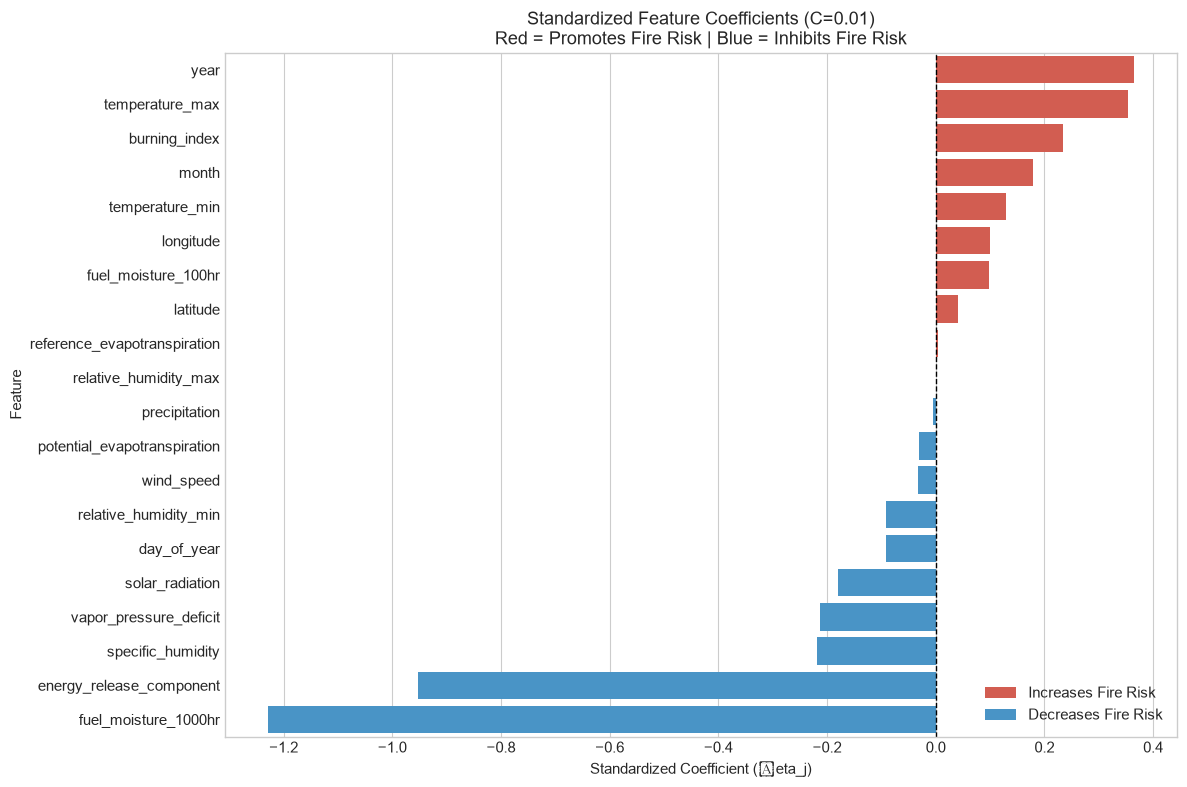

,Feature,Coefficient (Beta),Odds Ratio (exp(Beta)),Impact Direction
0,year,0.364218,1.439387,Increases Fire Risk
1,temperature_max,0.354396,1.425320,Increases Fire Risk
2,burning_index,0.234154,1.263839,Increases Fire Risk
3,month,0.177994,1.194818,Increases Fire Risk
4,temperature_min,0.128347,1.136947,Increases Fire Risk
5,longitude,0.099710,1.104850,Increases Fire Risk
6,fuel_moisture_100hr,0.098638,1.103667,Increases Fire Risk
7,latitude,0.041441,1.042312,Increases Fire Risk
8,reference_evapotranspiration,0.004484,1.004495,Increases Fire Risk
9,relative_humidity_max,0.000792,1.000792,Increases Fire Risk


In [15]:
coefs = champion_lr.coef_[0]
odds_ratios = np.exp(coefs)

feat_importance_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Coefficient (Beta)": coefs,
    "Odds Ratio (exp(Beta))": odds_ratios,
    "Impact Direction": ["Increases Fire Risk" if c > 0 else "Decreases Fire Risk" for c in coefs]
}).sort_values(by="Coefficient (Beta)", ascending=False)

plt.figure(figsize=(12, 8))
palette = {"Increases Fire Risk": "#e74c3c", "Decreases Fire Risk": "#3498db"}
sns.barplot(
    data=feat_importance_df,
    x="Coefficient (Beta)",
    y="Feature",
    hue="Impact Direction",
    palette=palette,
    dodge=False
)
plt.axvline(0, color='black', lw=1, linestyle='--')
plt.title(f"Standardized Feature Coefficients (C={best_c})\nRed = Promotes Fire Risk | Blue = Inhibits Fire Risk", fontsize=13)
plt.xlabel("Standardized Coefficient (\beta_j)")
plt.ylabel("Feature")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

display(feat_importance_df.reset_index(drop=True))


## 9. Final Generalization Evaluation on Test Set (2023–2025)

We now perform the final unbiased benchmark on the held-out **Test Set ($2023–2025$)** using the champion model and optimal threshold $\tau^*$.
This evaluation is identical to the one Members 2, 3, and 4 will run, enabling the stage-7 fair comparison.


In [16]:
# Inference on test set
y_test_proba = champion_lr.predict_proba(X_test_scaled)[:, 1]
y_test_pred_default = (y_test_proba >= 0.50).astype(int)
y_test_pred_opt = (y_test_proba >= optimal_threshold).astype(int)

# Test metrics
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)
test_f1_opt = f1_score(y_test, y_test_pred_opt)
test_prec_opt = precision_score(y_test, y_test_pred_opt)
test_rec_opt = recall_score(y_test, y_test_pred_opt)
test_f1_default = f1_score(y_test, y_test_pred_default)

print("=" * 65)
print("       MEMBER 1 (LOGISTIC REGRESSION) FINAL TEST EVALUATION")
print("=" * 65)
print(f"Test ROC-AUC Score:                         {test_roc_auc:.4f}")
print(f"Test PR-AUC (Average Precision):            {test_pr_auc:.4f}")
print(f"Test F1-Score (@ optimal tau = {optimal_threshold:.2f}):      {test_f1_opt:.4f}")
print(f"Test F1-Score (@ default tau = 0.50):        {test_f1_default:.4f}")
print(f"Test Precision (@ optimal tau):             {test_prec_opt:.4f}")
print(f"Test Recall (@ optimal tau):                {test_rec_opt:.4f}")
print("=" * 65)
print("\nFinal Test Classification Report (Optimal Threshold):")
print(classification_report(y_test, y_test_pred_opt, target_names=["No wildfire (0)", "wildfire (1)"]))


       MEMBER 1 (LOGISTIC REGRESSION) FINAL TEST EVALUATION
Test ROC-AUC Score:                         0.5762
Test PR-AUC (Average Precision):            0.1785
Test F1-Score (@ optimal tau = 0.72):      0.2674
Test F1-Score (@ default tau = 0.50):        0.2524
Test Precision (@ optimal tau):             0.1641
Test Recall (@ optimal tau):                0.7209

Final Test Classification Report (Optimal Threshold):
                 precision    recall  f1-score   support

No wildfire (0)       0.89      0.38      0.54    705565
   wildfire (1)       0.16      0.72      0.27    118390

       accuracy                           0.43    823955
      macro avg       0.53      0.55      0.40    823955
   weighted avg       0.79      0.43      0.50    823955



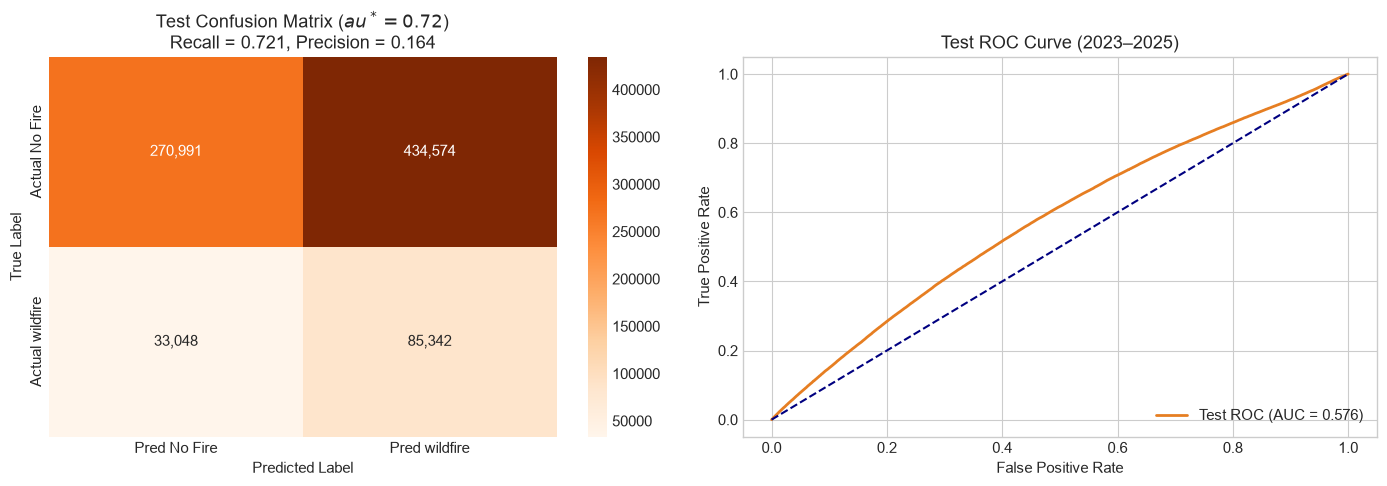

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_test = confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(cm_test, annot=True, fmt=',d', cmap='Oranges', ax=axes[0],
            xticklabels=['Pred No Fire', 'Pred wildfire'],
            yticklabels=['Actual No Fire', 'Actual wildfire'])
axes[0].set_title(f"Test Confusion Matrix ($\tau^*={optimal_threshold:.2f}$)\nRecall = {test_rec_opt:.3f}, Precision = {test_prec_opt:.3f}")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

# Test ROC curve
fpr_t, tpr_t, _ = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr_t, tpr_t, color='#e67e22', lw=2, label=f'Test ROC (AUC = {test_roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='navy')
axes[1].set_title("Test ROC Curve (2023–2025)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 10. Artifact Export & Stage 7 Team Comparison Preparation

We export the finalized Member 1 model package to `ml/artifacts/`:
1. Trained `StandardScaler` (required for real-time feature normalization in production)
2. Champion `LogisticRegression` model object
3. Optimal probability threshold $\tau^*$
4. Feature list and ordering
5. Complete performance metrics dictionary


In [18]:
ARTIFACTS_DIR = "../artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
EXPORT_FILE = os.path.join(ARTIFACTS_DIR, "logistic_regression_pipeline.joblib")

pipeline_artifact = {
    "member": "Member 1",
    "model_name": "Logistic Regression",
    "model": champion_lr,
    "scaler": scaler,
    "feature_names": FEATURE_COLS,
    "optimal_threshold": float(optimal_threshold),
    "hyperparameters": {
        "C": float(best_c),
        "penalty": "l2",
        "solver": "lbfgs",
        "class_weight": "balanced"
    },
    "metrics": {
        "val_roc_auc": float(tuning_df.loc[tuning_df['C'] == best_c, 'Val ROC-AUC'].values[0]),
        "val_pr_auc": float(tuning_df.loc[tuning_df['C'] == best_c, 'Val PR-AUC'].values[0]),
        "val_f1": float(tuning_df.loc[tuning_df['C'] == best_c, 'Val F1 (Optimal Threshold)'].values[0]),
        "test_roc_auc": float(test_roc_auc),
        "test_pr_auc": float(test_pr_auc),
        "test_f1": float(test_f1_opt),
        "test_precision": float(test_prec_opt),
        "test_recall": float(test_rec_opt)
    }
}

joblib.dump(pipeline_artifact, EXPORT_FILE)
print(f"Member 1 model artifact successfully exported to: {EXPORT_FILE}")


Member 1 model artifact successfully exported to: ../artifacts\logistic_regression_pipeline.joblib


## 11. Member 1 Model Card (Ready for Stage 7 Group Comparison)

| Dimension | Specification | Notes / Academic Justification |
| :--- | :--- | :--- |
| **Team Member** | Member 1 | Dedicated to linear/probabilistic baseline |
| **Model** | Logistic Regression | Parametric linear classifier |
| **Scaling** | `StandardScaler` (Train fit only) | Essential for regularized linear models; zero leakage |
| **Imbalance Handling** | `class_weight='balanced'` | Inversely scales penalty with class frequency |
| **Hyperparameter ($C$)** | Optimized via validation PR-AUC | Balances regularization bias vs. variance |
| **Threshold ($\tau^*$)** | Optimized via validation F1 sweep | Adapts to class imbalance |
| **Validation Period** | 2021–2022 ($1.32	ext{M}$ records) | Common group validation split |
| **Test Period** | 2023–2025 ($824	ext{k}$ records) | Common group benchmark split |
| **Artifact Destination** | `ml/artifacts/logistic_regression_pipeline.joblib` | Integrated with FastAPI backend |


## 12. Logistic Regression Experiment Comparison

### Objective
Consolidate and compare the performance across all three Logistic Regression experimental setups:
1. **Baseline Logistic Regression**: Unweighted model without class balancing.
2. **Optimized Logistic Regression**: Hyperparameter-tuned model ($C=0.01$, `class_weight='balanced'`) with optimal decision threshold ($\tau^*=0.72$).
3. **Logistic Regression - Selected Features**: Champion model trained strictly on the top 15 standardized features.


In [28]:
# ============================================================
# STEP 12.1 — LOGISTIC REGRESSION EXPERIMENT COMPARISON
# ============================================================

lr_experiment_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Optimized Logistic Regression",
        "Logistic Regression - Selected Features"
    ],
    "Accuracy": [
        0.918432,
        0.581698,
        0.581894
    ],
    "Precision": [
        0.000000,
        0.106552,
        0.106319
    ],
    "Recall": [
        0.000000,
        0.558996,
        0.557120
    ],
    "F1-score": [
        0.000000,
        0.178986,
        0.178562
    ],
    "ROC-AUC": [
        0.604128,
        0.603731,
        0.602248
    ]
})

print("Logistic Regression Experiment Comparison")
print("-----------------------------------------")
print(
    lr_experiment_comparison.to_string(index=False)
)


Logistic Regression Experiment Comparison
-----------------------------------------
                                  Model  Accuracy  Precision   Recall  F1-score  ROC-AUC
           Baseline Logistic Regression  0.918432   0.000000 0.000000  0.000000 0.604128
          Optimized Logistic Regression  0.581698   0.106552 0.558996  0.178986 0.603731
Logistic Regression - Selected Features  0.581894   0.106319 0.557120  0.178562 0.602248
